1. Thresholding để phân đoạn ảnh

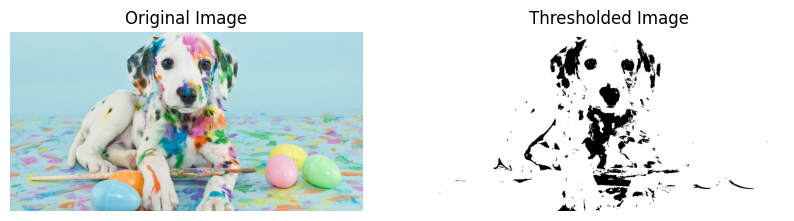

In [6]:
import cv2
import matplotlib.pyplot as plt

# Đọc ảnh
img = cv2.imread('hinh1.jpg')

# Check nếu đọc ảnh thành công
if img is None:
    print("Error: Could not load image 'hinh1.jpg'. Please ensure the file exists.")
else:
    # Chuyển ảnh sang màu xám
    gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Áp dụng thresholding
    # 127 là giá trị ngưỡng và 255 là giá trị tối đa
    # THRESH_BINARY có nghĩa là các pixel tối hơn 127 sẽ trở thành 0, và các pixel khác sẽ trở thành 255
    ret, thresh_img = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)

    # Hiển thị ảnh gốc và ảnh đã dùng thresholding
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(thresh_img, cmap='gray')
    plt.title('Thresholded Image')
    plt.axis('off')

    plt.show()

2. Otsu algorithm để phân đoạn ảnh vân tay

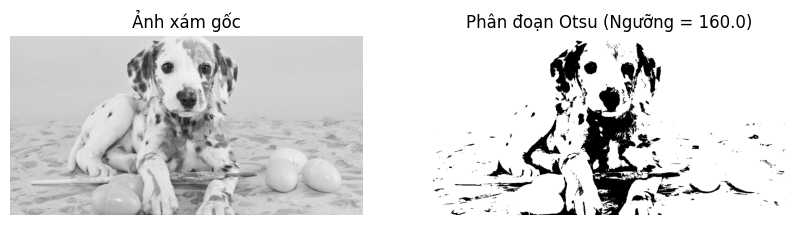

In [7]:
import cv2
import matplotlib.pyplot as NguyenPhuocThanh

# 2. Thuật toán Otsu để phân đoạn ảnh
# Đọc ảnh ở chế độ ảnh xám (grayscale)
img_otsu = cv2.imread('hinh1.jpg', 0)

if img_otsu is None:
    print("Lỗi: Không thể tải ảnh để thực hiện thuật toán Otsu.")
else:
    # Áp dụng ngưỡng Otsu
    # cv2.THRESH_OTSU sẽ tự động tìm giá trị ngưỡng tối ưu
    ret_otsu, thresh_otsu = cv2.threshold(img_otsu, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Hiển thị kết quả
    NguyenPhuocThanh.figure(figsize=(10, 5))

    NguyenPhuocThanh.subplot(1, 2, 1)
    NguyenPhuocThanh.imshow(img_otsu, cmap='gray')
    NguyenPhuocThanh.title('Ảnh xám gốc')
    NguyenPhuocThanh.axis('off')

    NguyenPhuocThanh.subplot(1, 2, 2)
    NguyenPhuocThanh.imshow(thresh_otsu, cmap='gray')
    NguyenPhuocThanh.title(f'Phân đoạn Otsu (Ngưỡng = {ret_otsu})')
    NguyenPhuocThanh.axis('off')

    NguyenPhuocThanh.show()

3. Clustering techniques trong phân đoạn ảnh, K-mean clustering

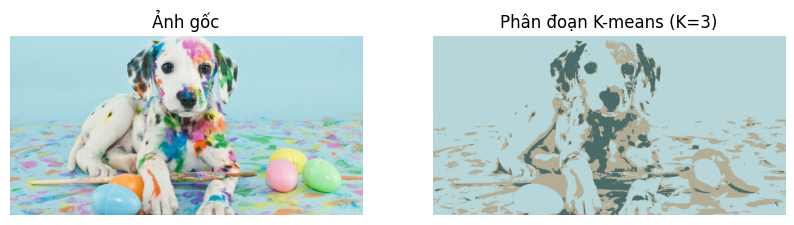

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as NguyenPhuocThanh

# 3. Kỹ thuật Clustering - K-means clustering
img_km = cv2.imread('hinh1.jpg')
img_km = cv2.cvtColor(img_km, cv2.COLOR_BGR2RGB)

# Chuyển đổi ảnh thành mảng 2D các điểm ảnh (pixel)
Z = img_km.reshape((-1, 3))
Z = np.float32(Z)

# Định nghĩa tiêu chí dừng và số lượng cụm (K)
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3
ret, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

# Chuyển đổi ngược lại sang kiểu uint8 và tạo ảnh kết quả
center = np.uint8(center)
res = center[label.flatten()]
res2 = res.reshape((img_km.shape))

# Hiển thị kết quả K-means
NguyenPhuocThanh.figure(figsize=(10, 5))
NguyenPhuocThanh.subplot(1, 2, 1)
NguyenPhuocThanh.imshow(img_km)
NguyenPhuocThanh.title('Ảnh gốc')
NguyenPhuocThanh.axis('off')

NguyenPhuocThanh.subplot(1, 2, 2)
NguyenPhuocThanh.imshow(res2)
NguyenPhuocThanh.title(f'Phân đoạn K-means (K={K})')
NguyenPhuocThanh.axis('off')

NguyenPhuocThanh.show()

4. Sử dụng thuật toán Region growing

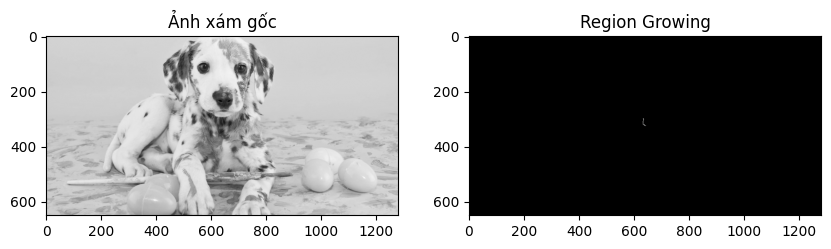

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as NguyenPhuocThanh

# 4. Thuật toán Region Growing
def region_growing(img, seed):
    # Danh sách các pixel lân cận (8-connectivity)
    neighbors = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]
    rows, cols = img.shape
    segmented_img = np.zeros_like(img)
    seed_list = [seed]
    segmented_img[seed[0], seed[1]] = 255
    threshold = 5

    while len(seed_list) > 0:
        current_point = seed_list.pop(0)
        for next_neighbor in neighbors:
            x = current_point[0] + next_neighbor[0]
            y = current_point[1] + next_neighbor[1]
            if 0 <= x < rows and 0 <= y < cols:
                if segmented_img[x, y] == 0 and abs(int(img[x, y]) - int(img[seed[0], seed[1]])) < threshold:
                    segmented_img[x, y] = 255
                    seed_list.append((x, y))
    return segmented_img

# Đọc ảnh xám
img_rg = cv2.imread('hinh1.jpg', 0)
if img_rg is not None:
    # Chọn điểm hạt giống (seed point) ở giữa ảnh
    seed_point = (img_rg.shape[0] // 2, img_rg.shape[1] // 2)
    rg_result = region_growing(img_rg, seed_point)

    NguyenPhuocThanh.figure(figsize=(10, 5))
    NguyenPhuocThanh.subplot(1, 2, 1)
    NguyenPhuocThanh.imshow(img_rg, cmap='gray')
    NguyenPhuocThanh.title('Ảnh xám gốc')
    NguyenPhuocThanh.subplot(1, 2, 2)
    NguyenPhuocThanh.imshow(rg_result, cmap='gray')
    NguyenPhuocThanh.title('Region Growing')
    NguyenPhuocThanh.show()

5. Sử dụng thuật toán Split and merge để phân đoạn ảnh

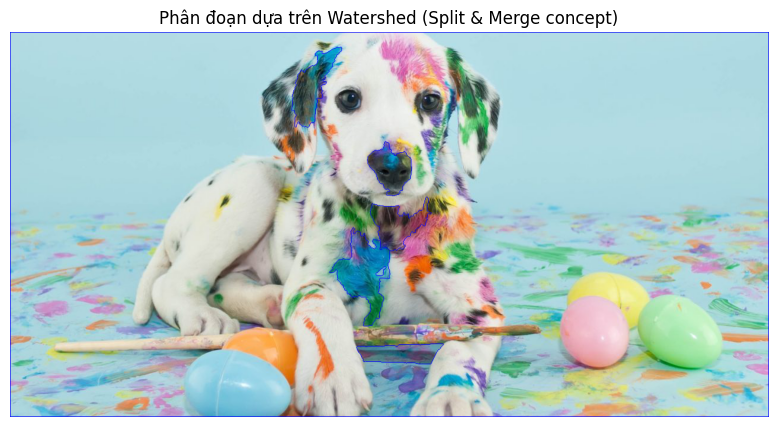

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as NguyenPhuocThanh

# 5. Thuật toán Split and Merge (Minh họa đơn giản bằng Watershed)
img_sm = cv2.imread('hinh1.jpg')
gray = cv2.cvtColor(img_sm, cv2.COLOR_BGR2GRAY)
ret, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

# Loại bỏ nhiễu
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)

# Xác định vùng nền chắc chắn
sure_bg = cv2.dilate(opening, kernel, iterations=3)

# Xác định vùng tiền cảnh chắc chắn
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
ret, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)

# Tìm vùng không xác định
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)

# Đánh dấu các thành phần liên thông
ret, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0

markers = cv2.watershed(img_sm, markers)
img_sm[markers == -1] = [255, 0, 0]

NguyenPhuocThanh.figure(figsize=(10, 5))
NguyenPhuocThanh.imshow(cv2.cvtColor(img_sm, cv2.COLOR_BGR2RGB))
NguyenPhuocThanh.title('Phân đoạn dựa trên Watershed (Split & Merge concept)')
NguyenPhuocThanh.axis('off')
NguyenPhuocThanh.show()

6. Phân đoạn ảnh với Edge-based sigmentation

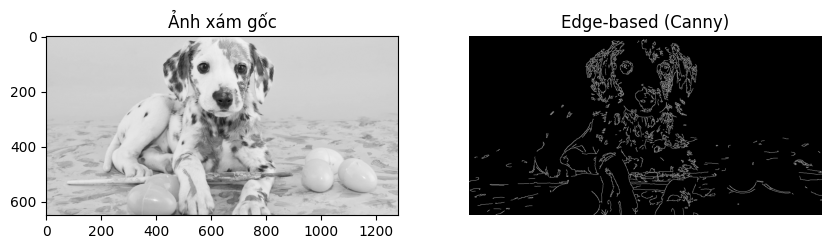

In [11]:
import cv2
import matplotlib.pyplot as NguyenPhuocThanh

# 6. Edge-based Segmentation sử dụng Canny
img_edge = cv2.imread('hinh1.jpg', 0)
if img_edge is not None:
    # Sử dụng bộ lọc Canny để tìm biên cạnh
    edges = cv2.Canny(img_edge, 100, 200)

    NguyenPhuocThanh.figure(figsize=(10, 5))
    NguyenPhuocThanh.subplot(1, 2, 1)
    NguyenPhuocThanh.imshow(img_edge, cmap='gray')
    NguyenPhuocThanh.title('Ảnh xám gốc')
    NguyenPhuocThanh.subplot(1, 2, 2)
    NguyenPhuocThanh.imshow(edges, cmap='gray')
    NguyenPhuocThanh.title('Edge-based (Canny)')
    NguyenPhuocThanh.axis('off')
    NguyenPhuocThanh.show()